# Lecture 3 participant notebook: Clebsch-Gordan coefficients

This notebook treats CG coefficients as library-provided representation data. It explores the triangle
rule, physical $1\otimes1$ products, and the intertwining identity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def random_rotation(rng):
    """Return a random proper 3D rotation using a unit quaternion."""
    q = rng.normal(size=4)
    q /= np.linalg.norm(q)
    w, x, y, z = q
    return np.array([
        [1-2*(y*y+z*z), 2*(x*y-z*w),   2*(x*z+y*w)],
        [2*(x*y+z*w),   1-2*(x*x+z*z), 2*(y*z-x*w)],
        [2*(x*z-y*w),   2*(y*z+x*w),   1-2*(x*x+y*y)],
    ])

In [2]:
# Spherical basis and Wigner D matrices
# Shared setup, identical in Lectures 2-5. Lecture 2 walks through it line by
# line; in later lectures just run it and move on.
from sympy.physics.wigner import clebsch_gordan  # Load tabulated CG coefficients from SymPy.

SQ2 = np.sqrt(2.0)  # Store sqrt(2), which appears repeatedly in the spherical basis.
U1 = np.array([  # Define the unitary change of basis from Cartesian (x,y,z) to m=(-1,0,+1).
    [1/SQ2, -1j/SQ2, 0],   # m=-1: v_-1 = (v_x - i v_y)/sqrt(2).
    [0,      0,       1],   # m= 0: v_0  = v_z.
    [-1/SQ2, -1j/SQ2, 0],  # m=+1: v_+1 = -(v_x + i v_y)/sqrt(2).
], dtype=complex)  # Spherical components are complex even for a real Cartesian vector.

def cart_to_sph(v):
    """Convert Cartesian vectors to spherical l=1 components.

    Inputs
    ------
    v : array, shape (..., 3)
        Real or complex vectors whose final axis is ordered (x, y, z).

    Returns
    -------
    array, shape (..., 3)
        Complex spherical components ordered by m=(-1, 0, +1).
    """
    v = np.asarray(v)  # Accept a list or ndarray and preserve any leading batch axes.
    return v @ U1.T  # Apply U1 to the final axis; row-vector storage requires the transpose.

def sph_to_cart(v_sph):
    """Convert spherical l=1 components back to Cartesian vectors.

    Inputs
    ------
    v_sph : array, shape (..., 3)
        Spherical components ordered by m=(-1, 0, +1).

    Returns
    -------
    array, shape (..., 3)
        Cartesian components ordered (x, y, z); physical real vectors become real arrays.
    """
    v_sph = np.asarray(v_sph)  # Accept a list or ndarray and preserve leading axes.
    v_cart = v_sph @ U1.conj()  # Apply U1^dagger; row-vector storage gives U1.conjugate().
    return np.real_if_close(v_cart, tol=1000)  # Remove round-off-sized imaginary parts only.

def cg_tensor(l1, l2, L):
    """Load one Clebsch-Gordan coupling tensor in the spherical basis.

    Inputs
    ------
    l1, l2 : int
        Angular momenta of the two input irreps.
    L : int
        Angular momentum of the coupled output irrep.

    Returns
    -------
    C : complex array, shape (2*L+1, 2*l1+1, 2*l2+1)
        C[M+L,m1+l1,m2+l2] equals <l1 m1,l2 m2 | L M>, including the
        fixed phase that preserves the reality convention for physical tensors.
    """
    C = np.zeros((2*L+1, 2*l1+1, 2*l2+1), dtype=complex)  # Allocate axes (M,m1,m2).
    for M in range(-L, L+1):  # Visit each output magnetic index M=-L,...,+L.
        for m1 in range(-l1, l1+1):  # Visit each magnetic index of the first input.
            m2 = M - m1  # The selection rule M=m1+m2 fixes the second magnetic index.
            if -l2 <= m2 <= l2:  # Skip combinations outside the second irrep's valid range.
                coefficient = clebsch_gordan(l1, l2, L, m1, m2, M)  # Ask SymPy for the CGC.
                C[M+L, m1+l1, m2+l2] = float(coefficient)  # Store it using zero-based indices.
    reality_phase = (-1j)**(l1+l2-L)  # Choose the phase making real inputs map to real tensors.
    return reality_phase * C  # Return fixed representation data, not a learnable parameter.

L_MAX = 2  # Highest irrep this course carries. This is a budget choice, NOT a symmetry
           # rule: the triangle rule genuinely allows 1x2->3 and 2x2->3,4, and we simply
           # do not build them. Raise L_MAX to get them, at rising cost.

CG = {}  # Map every allowed key (l1,l2,L) to its fixed Clebsch-Gordan tensor.
for l1 in range(L_MAX+1):  # Include first-input irreps l1=0,...,L_MAX.
    for l2 in range(l1, L_MAX+1):  # Store only l1<=l2; cg_product handles the reversed order.
        for L in range(abs(l1-l2), min(l1+l2, L_MAX)+1):  # Triangle rule, then truncate at L_MAX.
            CG[(l1, l2, L)] = cg_tensor(l1, l2, L)  # Load this coupling from SymPy once.

def D_sph(l, R):
    """Construct the Wigner D matrix for a 3D rotation.

    Inputs
    ------
    l : int
        Irrep degree; this compact example supports l=0,1,2.
    R : array, shape (3, 3)
        Active Cartesian rotation matrix acting as v_rotated = R @ v.

    Returns
    -------
    D : complex array, shape (2*l+1, 2*l+1)
        Wigner D^l(R), acting on m=-l,...,+l spherical components.
    """
    if l == 0:  # A scalar has one component and is unchanged by every rotation.
        return np.ones((1, 1), dtype=complex)  # D^0(R)=1.
    R = np.asarray(R)  # Normalize the input to an ndarray before matrix multiplication.
    D1 = U1 @ R @ U1.conj().T  # Rewrite the Cartesian rotation in the spherical l=1 basis.
    if l == 1:  # A spherical vector transforms directly with this 3x3 matrix.
        return D1  # Return D^1(R).
    if l == 2:  # Build the five-dimensional irrep from the 1 tensor 1 -> 2 coupling.
        C112 = CG[(1, 1, 2)]  # Fetch the fixed CG tensor selecting total angular momentum L=2.
        return np.einsum('Mab,ai,bj,Nij->MN', C112, D1, D1, C112.conj())  # C (D1 x D1) C^dagger;
        # the conjugate matters: C(1,1,2) happens to be real, but a coupling whose
        # phase (-i)^(l1+l2-L) is odd is not, and C^T would then be the wrong matrix.
    raise ValueError("this compact example implements l=0,1,2")  # Reject unsupported irreps.

def rotate_sph_features(features, R):
    """Rotate every multiplet in a feature dictionary.

    Inputs
    ------
    features : dict[int, array(batch, channels, 2*l+1)]
        Spherical features grouped by irrep degree l.
    R : array, shape (3, 3)
        Cartesian rotation applied to every sample and channel.

    Returns
    -------
    dict[int, array(batch, channels, 2*l+1)]
        A new dictionary with D^l(R) applied along every magnetic-index axis.
    """
    rotated = {}  # Create a new dictionary so the input features are not modified.
    for l, values in features.items():  # Process each irrep block independently.
        Dl = D_sph(l, R)  # Obtain the correct generalized rotation for this l.
        rotated[l] = np.einsum('mn,bcn->bcm', Dl, values)  # Contract D's input m with the feature m.
    return rotated  # Return all rotated irrep blocks.

v_cart = rng.normal(size=(5, 3))  # Draw five real Cartesian vectors for a round-trip test.
v_reconstructed = sph_to_cart(cart_to_sph(v_cart))  # Convert Cartesian -> spherical -> Cartesian.
roundtrip_error = np.max(np.abs(v_reconstructed - v_cart))  # Compare reconstruction to the original.
print(f"Cartesian <-> spherical round-trip: {roundtrip_error:.1e}")  # Expect floating-point error.

Ra = random_rotation(rng)  # Draw the first rotation used in the representation-law check.
Rb = random_rotation(rng)  # Draw the second rotation used in the representation-law check.
for l in (0, 1, 2):  # Test every irrep implemented in this example.
    hom = np.max(np.abs(D_sph(l, Ra) @ D_sph(l, Rb) - D_sph(l, Ra @ Rb)))  # Check D(Ra)D(Rb)=D(RaRb).
    unit = np.max(np.abs(D_sph(l, Ra) @ D_sph(l, Ra).conj().T - np.eye(2*l+1)))  # Check D D^dagger=I.
    print(f"l={l}: representation {hom:.1e}, unitary {unit:.1e}")  # Both errors should be near 1e-15.

Cartesian <-> spherical round-trip: 2.2e-16
l=0: representation 0.0e+00, unitary 0.0e+00
l=1: representation 2.2e-16, unitary 1.2e-16
l=2: representation 3.3e-16, unitary 2.2e-16


## 1. Define and verify the CG product

In [3]:
# Verify that each CG tensor is an equivariant map
def cg_product(x, y, l1, l2, L): # Eq. (14) in the lecture note
    """Couple two spherical multiplets into total angular momentum L.

    Inputs
    ------
    x : array, shape (..., 2*l1+1)
        First spherical feature, ordered by m1=-l1,...,+l1.
    y : array, shape (..., 2*l2+1)
        Second spherical feature, ordered by m2=-l2,...,+l2.
    l1, l2 : int
        Irrep degrees of x and y.
    L : int
        Requested output irrep, satisfying |l1-l2| <= L <= l1+l2.

    Returns
    -------
    array, shape (..., 2*L+1)
        Coupled spherical feature ordered by M=-L,...,+L.
    """
    if l1 <= l2:  # CG stores only keys with the smaller irrep first.
        key = (l1, l2, L)  # Use the stored order directly.
        swap = False  # The tensor's m axes already match x and y.
    else:  # Reverse the lookup order when l1>l2.
        key = (l2, l1, L)  # Look up the canonical stored key.
        swap = True  # Record that the two input axes must be exchanged.
    C = CG[key]  # Fetch the fixed Clebsch-Gordan tensor.
    if swap:  # Align the tensor axes with the actual x,y order.
        # Exchanging the two irreps is not just an axis swap; it costs a sign, because
        # <l1 m1, l2 m2 | L M> = (-1)^(l1+l2-L) <l2 m2, l1 m1 | L M>.
        C = C.swapaxes(1, 2) * (-1.0)**(l1+l2-L)  # Swap the m axes and apply that sign.
    return np.einsum('Mij,...i,...j->...M', C, x, y)  # Sum C[M,m1,m2]x[m1]y[m2]

R = random_rotation(rng)  # Use one common rotation for all CG equivariance tests.
paths = [(1,1,0), (1,1,1), (1,1,2), (1,2,1), (2,2,2)]  # Select representative legal couplings.
print("  path          max |CG(Dx,Dy)-D CG(x,y)|")  # Label the residual printed below.
for l1, l2, L in paths:  # Test one input/output irrep combination at a time.
    x = rng.normal(size=2*l1+1) + 1j*rng.normal(size=2*l1+1)  # Draw a generic complex l1 multiplet.
    y = rng.normal(size=2*l2+1) + 1j*rng.normal(size=2*l2+1)  # Draw a generic complex l2 multiplet.
    
    x_rot = D_sph(l1, R) @ x  # Rotate x using the Wigner matrix for l1.
    y_rot = D_sph(l2, R) @ y  # Rotate y using the Wigner matrix for l2.

    # Intertwining identity, Eq. (21) in the lecture note
    lhs = cg_product(x_rot, y_rot, l1, l2, L)  # Route 1: rotate inputs, then couple them.
    rhs = D_sph(L, R) @ cg_product(x, y, l1, l2, L)  # Route 2: couple first, then rotate the output.
    residual = np.max(np.abs(lhs-rhs))  # Equivariance requires the two routes to agree.
    print(f" {l1} x {l2} -> {L}              {residual:.1e}")  # Expect about machine precision.

# Uncomment if you want to inspect the CGs
# print("\nExample C^{1M}_{1m1,1m2} including the spherical reality phase:")  # Introduce one CG table.
# print(np.round(CG[(1,1,1)].reshape(3,9), 3))  # Show rows M and flattened columns (m1,m2).

  path          max |CG(Dx,Dy)-D CG(x,y)|
 1 x 1 -> 0              0.0e+00
 1 x 1 -> 1              1.5e-16
 1 x 1 -> 2              9.9e-16
 1 x 2 -> 1              6.2e-16
 2 x 2 -> 2              5.0e-16


## 2. Connect $1\otimes1$ to dot, cross, and quadrupole pieces

The convention fixes the normalization exactly: with these spherical components and
the $(-i)^{\ell_1+\ell_2-L}$ phase, the $L=0$ output is $(u\cdot v)/\sqrt3$ and the
$L=1$ output is $(u\times v)/\sqrt2$. Nothing here has to be fitted or estimated.

In [4]:
# Connect 1 x 1 -> L to the familiar Cartesian operations
# With this basis and phase convention the normalizations are exact numbers, not
# something to be fitted: the L=0 output is (u.v)/sqrt(3) and the L=1 output, converted
# back to Cartesian, is (u x v)/sqrt(2). The factors are the CG normalization itself.

u, v = rng.normal(size=(2, 3))  # Two arbitrary real Cartesian vectors.
us, vs = cart_to_sph(u), cart_to_sph(v)  # Their l=1 spherical components.

# The scalar piece, one component.
z0_sph = cg_product(us, vs, 1, 1, 0)  
z0_cart = u@v
print("L=0 output :", np.round(z0_sph.real, 6), "   (u.v)/sqrt(3) =", round(z0_cart/np.sqrt(3), 6), "    residual =", abs(z0_sph.real - z0_cart/np.sqrt(3)))

# The vector piece, back in Cartesian.
z1_sph = cg_product(us, vs, 1, 1, 1)
z1_cart = np.cross(u, v)
print("\nL=1 output :", np.round(z1_sph, 6))
print("(u x v)/sqrt(2):", np.round(cart_to_sph(z1_cart)/np.sqrt(2), 6))
print("residual =", np.max(np.abs(z1_sph - cart_to_sph(z1_cart)/np.sqrt(2))))

# The quadrupole piece, five components.
z2_sph = cg_product(us, vs, 1, 1, 2)  
print("\nL=2 output:", z2_sph, "- the symmetric-traceless piece, five components")

print("\nSo the dot and cross products of Lecture 1 were these two CG couplings all along,")
print("up to a fixed normalization that representation theory hands you for free.")

L=0 output : [-0.675092]    (u.v)/sqrt(3) = -0.675092     residual = [1.11022302e-16]

L=1 output : [-0.302571+0.65412j -0.567475+0.j       0.302571+0.65412j]
(u x v)/sqrt(2): [-0.302571+0.65412j -0.567475+0.j       0.302571+0.65412j]
residual = 1.1102230246251565e-16

L=2 output: [ 0.30074517+0.2665396j   0.19125151-0.65563017j -1.00823195+0.j
 -0.19125151-0.65563017j  0.30074517-0.2665396j ] - the symmetric-traceless piece, five components

So the dot and cross products of Lecture 1 were these two CG couplings all along,
up to a fixed normalization that representation theory hands you for free.


## 3. Shape is not enough: corrupt a coupling and watch it fail

Section 1 showed the CG tensors intertwine. This section asks the converse question, which is the one
that matters when you are debugging: **how wrong does a coupling table have to be before the test
notices?**

Two corruptions, all of the correct shape, all of which a program would happily run:

* a **random** tensor, normalised to the same size as the real one;
* the real tensor **perturbed** by a controlled amount $\varepsilon$, to see how the residual scales.

The second is the useful one. A test that only fires for a completely random tensor is a weak test; what
you want to know is whether it catches a table that is nearly right.

path 1 x 2 -> 2,  tensor shape (5, 3, 5)

tensor                                residual
library CG (correct)                   7.3e-16
random, same shape and norm            4.2e+00

now perturb the true table, on ONE fixed test pair so only epsilon varies:

   epsilon      residual    residual/epsilon
     1e-08     4.957e-08            4.956912
     1e-06     4.957e-06            4.956911
     1e-04     4.957e-04            4.956911
     1e-02     4.957e-02            4.956911
     1e-01     4.957e-01            4.956911
     1e+00     4.957e+00            4.956911


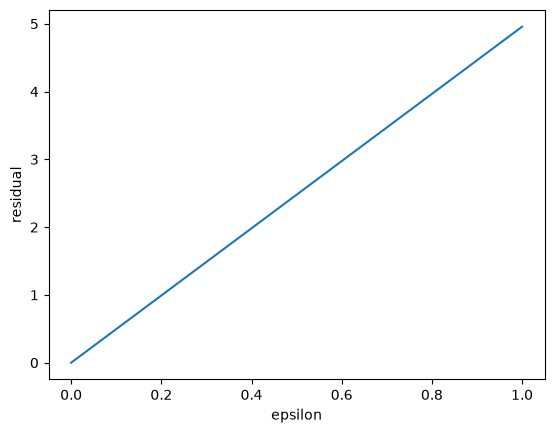


The ratio is constant to six decimals over eight decades. That is not approximate linearity,
it is an identity: the test is linear in the tensor, so for C + eps*N the correct part cancels
exactly and what is left is eps times the residual of N.


In [5]:
# Corrupt a coupling table and measure how loudly the intertwining test complains.
def residual(C, l1, l2, L, rot, trials=4, xy=None):
    """Max |C(Dx,Dy) - D C(x,y)| for an arbitrary tensor C of the right shape.

    Pass xy=(x, y) to hold the test multiplets fixed. The residual scales with |x||y|, so
    drawing fresh inputs on every call adds a factor of a few of noise -- enough to hide
    the scaling measured below.
    """
    worst = 0.0  # Track the largest residual over a few random multiplets.
    for _ in range(trials):  # Repeat so a single lucky pair cannot hide a break.
        x = rng.normal(size=2*l1+1) + 1j*rng.normal(size=2*l1+1)  # Generic complex l1 input.
        y = rng.normal(size=2*l2+1) + 1j*rng.normal(size=2*l2+1)  # Generic complex l2 input.
        
        if xy is not None: x, y = xy  # Use the caller's fixed pair instead.
        
        lhs = np.einsum('Mij,i,j->M', C, D_sph(l1, rot) @ x, D_sph(l2, rot) @ y)  # Rotate, then couple.
        rhs = D_sph(L, rot) @ np.einsum('Mij,i,j->M', C, x, y)  # Couple, then rotate.
        
        worst = max(worst, np.max(np.abs(lhs - rhs)))  # Keep the worst disagreement.
    return worst

l1, l2, L = 1, 2, 2  # A path with l1 != l2; L_MAX=2 in the shared setup
C_true = CG[(l1, l2, L)]  # The library tensor, correct by construction.
scale = np.linalg.norm(C_true)  # Match every corruption to the true tensor's size.

C_rand = rng.normal(size=C_true.shape) + 1j*rng.normal(size=C_true.shape)  # Same shape, no structure.
C_rand *= scale/np.linalg.norm(C_rand)  # Normalise so size cannot explain the difference.

print(f"path {l1} x {l2} -> {L},  tensor shape {C_true.shape}\n")
print(f"{'tensor':<34}{'residual':>12}")
print(f"{'library CG (correct)':<34}{residual(C_true, l1, l2, L, R):12.1e}")
print(f"{'random, same shape and norm':<34}{residual(C_rand, l1, l2, L, R):12.1e}")

print("\nnow perturb the true table, on ONE fixed test pair so only epsilon varies:\n")
print(f"{'epsilon':>10}{'residual':>14}{'residual/epsilon':>20}")
noise = rng.normal(size=C_true.shape) + 1j*rng.normal(size=C_true.shape)  # One fixed direction.
noise *= scale/np.linalg.norm(noise)  # Same normalisation as the tensor itself.
x_fix = rng.normal(size=2*l1+1) + 1j*rng.normal(size=2*l1+1)  # Fixed inputs for the whole scan.
y_fix = rng.normal(size=2*l2+1) + 1j*rng.normal(size=2*l2+1)  # Without this the table is noisy.

eps = [1e-8, 1e-6, 1e-4, 1e-2, 1e-1, 1.0]
res = []
for ep in eps:  # Sweep the corruption over eight decades.
    re = residual(C_true + ep*noise, l1, l2, L, R, xy=(x_fix, y_fix))  # Slightly-wrong table.
    res.append(re)
    print(f"{ep:>10.0e}{re:14.3e}{re/ep:20.6f}")
    
import matplotlib.pyplot as plt
plt.plot(eps,res)
plt.xlabel("epsilon")
plt.ylabel("residual")
plt.show()

print("\nThe ratio is constant to six decimals over eight decades. That is not approximate linearity,")
print("it is an identity: the test is linear in the tensor, so for C + eps*N the correct part cancels")
print("exactly and what is left is eps times the residual of N.")

## Try it

1. List all nonzero entries of the $1\otimes1\to0$ table.
2. Verify the intertwining identity with physical real vectors rather than generic complex multiplets.
3. Repeat the perturbation scan of Section 3 for a path with $\ell_1=\ell_2$, where the swap branch is not used.
4. Use the triangle rule to check that $\dim(\ell_1\otimes\ell_2)=\sum_L(2L+1)$ for a few pairs by hand.